# Clustering Premier League Teams by Playing Style
## ECS784P/U Data Analytics — Coursework 1

**Module:** ECS784P/U Data Analytics  
**Institution:** Queen Mary University of London  
**Dataset:** English Premier League 2024–2025 Season (FBref)  
**Methods:** K-Means Clustering & Gaussian Mixture Models (GMM)

---
*All statistics are per-90-minute squad averages. Analysis covers all 20 EPL teams across 15 playing-style features.*

## Overview

### Objective
Our objective is to cluster English Premier League Teams on their playing style, explore similarities using two **Unsupervised Learning techniques: GMM and K-Means**.

## 1. Imports & Data Loading

In [6]:
# Data manipulation
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the pre-merged master dataset (produced by Data_Analytics_Data_Preprocessing.ipynb)
# 20 EPL squads × 47 raw columns; all statistics are per-90-minute averages
data = pd.read_csv('epl_2024_2025_master_stats.csv')

## 2. Exploratory Data Analysis (EDA)

We begin by inspecting the dataset's shape, column types, and missing values, then visualise feature correlations and use PCA to understand the intrinsic dimensionality before clustering.

### Shape, Columns

In [8]:
print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
data.head()

Shape: (20, 47)

Columns: ['Squad', '# Pl', 'Age', 'Poss', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKA', 'PKsv', 'PKm']


,Squad,# Pl,Age,Poss,MP,Starts,Min,90s,Gls,Ast,...,Saves,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm
0,Arsenal,25,25.8,56.9,38,418,"3,420",38.0,1.76,1.45,...,2.26,74.2,0.53,0.37,0.11,0.34,34.2,0.08,0.00,0.0
1,Aston Villa,28,27.0,50.5,38,418,"3,420",38.0,1.47,1.18,...,2.74,68.6,0.50,0.24,0.26,0.24,23.7,0.05,0.03,0.0
2,Bournemouth,29,25.1,48.5,38,418,"3,420",38.0,1.50,1.08,...,3.32,75.6,0.39,0.29,0.32,0.24,23.7,0.11,0.00,0.0
3,Brentford,28,25.8,47.9,38,418,"3,420",38.0,1.71,1.16,...,4.03,72.9,0.42,0.21,0.37,0.21,21.1,0.03,0.00,0.0
4,Brighton,32,24.8,52.3,38,418,"3,420",38.0,1.68,1.08,...,2.37,66.0,0.42,0.34,0.24,0.21,21.1,0.24,0.00,0.0


### Check for missing values and data types

In [9]:
print(data.dtypes)
print("\nMissing values:")
print(data.isnull().sum())

Squad      object
# Pl        int64
Age       float64
Poss      float64
MP          int64
Starts      int64
Min        object
90s       float64
Gls       float64
Ast       float64
G+A       float64
G-PK      float64
PK        float64
PKatt     float64
CrdY      float64
CrdR      float64
G+A-PK    float64
Sh        float64
SoT       float64
SoT%      float64
Sh/90     float64
SoT/90    float64
G/Sh      float64
G/SoT     float64
2CrdY     float64
Fls       float64
Fld       float64
Off       float64
Crs       float64
Int       float64
TklW      float64
PKwon     float64
PKcon     float64
OG        float64
GA        float64
GA90      float64
SoTA      float64
Saves     float64
Save%     float64
W         float64
D         float64
L         float64
CS        float64
CS%       float64
PKA       float64
PKsv      float64
PKm       float64
dtype: object

Missing values:
Squad     0
# Pl      0
Age       0
Poss      0
MP        0
Starts    0
Min       0
90s       0
Gls       0
Ast       0
G+A

## 3. Feature Selection

We filter the 47 raw columns to retain only features that describe *how* a team plays, not *how well* they performed.

### Observations

The dataset is clean — no missing values and all columns are numeric (except `Squad` and `Min`).

We now identify and drop features that do not describe *how* a team plays:

- **Metadata** (`# Pl`, `Age`, `MP`, `Starts`, `Min`, `90s`): squad composition or scheduling constants, identical across teams
- **Outcome metrics** (`Gls`, `Ast`, `W`, `D`, `L`, `CS`, `G/Sh`, `G/SoT`, `GA`, `GA90`, etc.): measure results, not the manner of play
- **Rare events** (`PKwon`, `PKcon`, `2CrdY`, `OG`): too infrequent to reliably characterise a playing style

In [10]:
# Metadata columns (not style-related)
# Outcome columns (measure results, not how the team plays)

cols_to_drop = [
    '# Pl',       # squad size — not style
    'Age',        # average age — not style
    'MP',         # matches played — same for all
    'Starts',     # same for all
    'Min',        # same for all
    '90s',        # same for all
    'Gls',        # goals scored — outcome
    'Ast',        # assists — outcome
    'G+A',        # goals + assists — outcome
    'G-PK',       # non-penalty goals — outcome
    'PK',         # penalties scored — outcome
    'PKatt',      # penalties attempted — outcome
    'G+A-PK',     # outcome
    'G/Sh',       # goals per shot — outcome (finishing quality, not style)
    'G/SoT',      # goals per shot on target — outcome
    'GA',         # goals against — outcome
    'GA90',       # goals against per 90 — outcome
    'W',          # wins — outcome
    'D',          # draws — outcome
    'L',          # losses — outcome
    'CS',         # clean sheets — outcome
    'CS%',        # clean sheet % — outcome
    'PKwon',      # penalty events — too rare to define style
    'PKcon',      # penalty events
    'PKA',        # penalty events
    'PKsv',       # penalty events
    'PKm',        # penalty events
    'OG',         # own goals — random events
    '2CrdY',      # second yellows — too rare
]

data_style = data.drop(columns=cols_to_drop)

# Set Squad as index
data_style = data_style.set_index('Squad')

print("Shape:", data_style.shape)
data_style.columns.tolist()

Shape: (20, 17)


['Poss',
 'CrdY',
 'CrdR',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'Fls',
 'Fld',
 'Off',
 'Crs',
 'Int',
 'TklW',
 'SoTA',
 'Saves',
 'Save%']

## 3. Data Preprocessing

### 3.1 Feature Scaling (StandardScaler)

K-Means and GMM both rely on distance or covariance metrics. Without scaling, features with large numeric ranges (e.g. `Crs` ≈ 14–22 per 90) would dominate over features with small ranges (e.g. `CrdR` ≈ 0.03–0.13 per 90), regardless of statistical importance.

`StandardScaler` transforms each feature to **zero mean and unit standard deviation**, ensuring all 15 features contribute equally to the distance metric.

In [11]:
from sklearn.preprocessing import StandardScaler

# StandardScaler: transforms each feature to mean=0, std=1
# Essential for K-Means (Euclidean distance) and GMM (covariance-based) so that no
# feature dominates purely due to its scale rather than its discriminative power
scaler = StandardScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data_style),
    columns=data_style.columns,
    index=data_style.index
)

data_scaled.head()

,Poss,CrdY,CrdR,Sh,SoT,SoT%,Sh/90,SoT/90,Fls,Fld,Off,Crs,Int,TklW,SoTA,Saves,Save%
Squad,,,,,,,,,,,,,,,,,
Arsenal,1.194296,-0.900957,2.450526,0.669885,0.453202,-0.401850,0.677772,0.453202,-0.357210,-0.013767,1.304808,1.076918,-2.044911,-1.147978,-1.620975,-1.427017,1.276766
Aston Villa,0.087345,-0.351802,1.104083,-0.114146,-0.179762,-0.133950,-0.125582,-0.179762,-0.279302,2.346269,-0.688649,-0.693923,-1.639777,-0.611062,-0.410817,-0.488705,-0.140457
Bournemouth,-0.258577,1.535918,0.296217,1.038841,0.921596,-0.089300,1.042513,0.921596,2.135859,-0.210437,0.489303,1.777018,1.317696,-0.005966,0.124200,0.645090,1.631072
Brentford,-0.362353,-1.621723,-1.050225,-0.667579,0.288632,2.812949,-0.661151,0.288632,-2.055613,-1.764127,-0.054367,0.047360,-0.444634,-0.432090,1.296143,2.033011,0.947768
Brighton,0.398675,-0.180191,0.296217,0.439288,0.630432,0.535800,0.456157,0.630432,0.343966,0.084568,-1.413543,0.376819,0.355505,0.675833,-0.716541,-1.211987,-0.798453


### Check correlations before PCA

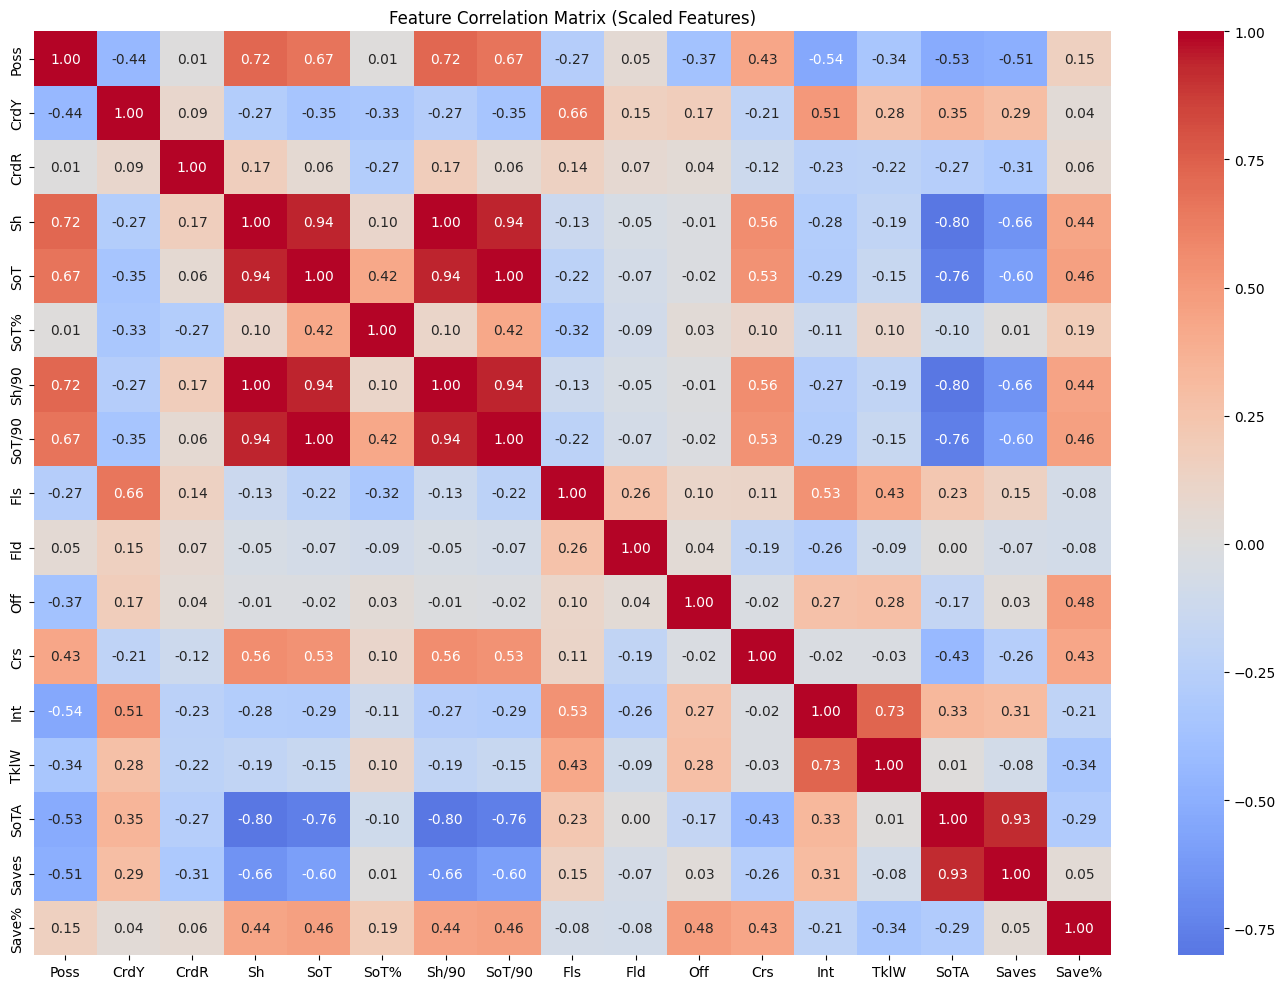

In [12]:
import os
# Ensure output directory exists for saving report figures
os.makedirs('dist/figures', exist_ok=True)

plt.figure(figsize=(14, 10))
sns.heatmap(data_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (Scaled Features)')
plt.tight_layout()
plt.savefig('dist/figures/fig_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
data_scaled.corr()

,Poss,CrdY,CrdR,Sh,SoT,SoT%,Sh/90,SoT/90,Fls,Fld,Off,Crs,Int,TklW,SoTA,Saves,Save%
Poss,1.000000,-0.441869,0.006032,0.723381,0.668081,0.013244,0.722639,0.668081,-0.269038,0.051699,-0.371987,0.432357,-0.540547,-0.340730,-0.526170,-0.506299,0.153499
CrdY,-0.441869,1.000000,0.087573,-0.274635,-0.349094,-0.328718,-0.271807,-0.349094,0.660632,0.150697,0.173693,-0.207232,0.505718,0.275844,0.347098,0.291656,0.038664
CrdR,0.006032,0.087573,1.000000,0.168439,0.059896,-0.274742,0.169735,0.059896,0.140953,0.069617,0.044979,-0.124374,-0.227360,-0.223029,-0.266966,-0.311108,0.062051
Sh,0.723381,-0.274635,0.168439,1.000000,0.941943,0.097968,0.999928,0.941943,-0.129990,-0.051549,-0.014599,0.559026,-0.275708,-0.194072,-0.802579,-0.660098,0.441242
SoT,0.668081,-0.349094,0.059896,0.941943,1.000000,0.424238,0.942357,1.000000,-0.219801,-0.071670,-0.015929,0.532407,-0.287705,-0.151847,-0.757254,-0.596121,0.461658
SoT%,0.013244,-0.328718,-0.274742,0.097968,0.424238,1.000000,0.099137,0.424238,-0.323493,-0.086803,0.029265,0.096353,-0.112153,0.096045,-0.102066,0.005848,0.193509
Sh/90,0.722639,-0.271807,0.169735,0.999928,0.942357,0.099137,1.000000,0.942357,-0.126236,-0.054703,-0.012189,0.558241,-0.273820,-0.192276,-0.802709,-0.659862,0.444002
SoT/90,0.668081,-0.349094,0.059896,0.941943,1.000000,0.424238,0.942357,1.000000,-0.219801,-0.071670,-0.015929,0.532407,-0.287705,-0.151847,-0.757254,-0.596121,0.461658
Fls,-0.269038,0.660632,0.140953,-0.129990,-0.219801,-0.323493,-0.126236,-0.219801,1.000000,0.261130,0.104119,0.114454,0.528246,0.425882,0.228532,0.145086,-0.077027
Fld,0.051699,0.150697,0.069617,-0.051549,-0.071670,-0.086803,-0.054703,-0.071670,0.261130,1.000000,0.042630,-0.194562,-0.261876,-0.094364,0.003795,-0.069903,-0.078421


**Key observation from the correlation matrix:**

- `Sh` and `Sh/90` have a near-perfect correlation of $r = 0.9999$
- `SoT` and `SoT/90` are identical ($r = 1.0$)

This is expected: since all 20 EPL teams played exactly 38 matches, per-90 and total values are directly proportional. Retaining both would **double-weight** those features in the distance metric. We drop `Sh/90` and `SoT/90` before re-scaling.

### PCA to understand dimensionality

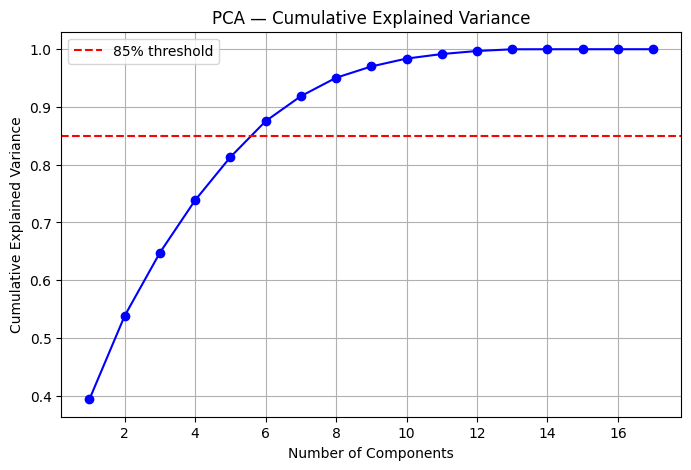

Variance explained per component:
  PC1: 0.394 (cumulative: 0.394)
  PC2: 0.144 (cumulative: 0.538)
  PC3: 0.109 (cumulative: 0.648)
  PC4: 0.091 (cumulative: 0.739)
  PC5: 0.075 (cumulative: 0.813)
  PC6: 0.062 (cumulative: 0.875)
  PC7: 0.043 (cumulative: 0.919)
  PC8: 0.032 (cumulative: 0.951)
  PC9: 0.020 (cumulative: 0.970)
  PC10: 0.014 (cumulative: 0.984)
  PC11: 0.008 (cumulative: 0.992)
  PC12: 0.005 (cumulative: 0.997)
  PC13: 0.003 (cumulative: 1.000)
  PC14: 0.000 (cumulative: 1.000)
  PC15: 0.000 (cumulative: 1.000)
  PC16: 0.000 (cumulative: 1.000)
  PC17: 0.000 (cumulative: 1.000)


In [14]:
from sklearn.decomposition import PCA

# Fit PCA with all 15 components to assess intrinsic dimensionality
# PCA is used for EXPLORATION ONLY — clustering is performed on all 15 scaled features
pca_full = PCA()
pca_full.fit(data_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_.cumsum(), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
plt.legend()
plt.grid(True)
plt.savefig('dist/figures/fig_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Variance explained per component:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} (cumulative: {sum(pca_full.explained_variance_ratio_[:i+1]):.3f})")

**Correlation matrix**: Sh and Sh/90 are almost perfectly correlated (0.999), and SoT and SoT/90 are identical (1.0). This makes sense — with all teams playing 38 matches, per-match and per-90 are the same thing. Similarly, SoTA and Saves are very highly correlated (0.93). We should drop the redundant columns before clustering to avoid giving those features double weight.

In [15]:
# Sh/90 is identical to Sh, SoT/90 is identical to SoT (same matches played)
data_style = data_style.drop(columns=['Sh/90', 'SoT/90'])

print("Shape after removing redundant features:", data_style.shape)
print("Remaining columns:", data_style.columns.tolist())

Shape after removing redundant features: (20, 15)
Remaining columns: ['Poss', 'CrdY', 'CrdR', 'Sh', 'SoT', 'SoT%', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'SoTA', 'Saves', 'Save%']


### Re-scale and re-run PCA

In [16]:
data_scaled = pd.DataFrame(
    scaler.fit_transform(data_style),
    columns=data_style.columns,
    index=data_style.index
)

pca_full = PCA()
pca_full.fit(data_scaled)

print("Variance explained per component:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} (cumulative: {sum(pca_full.explained_variance_ratio_[:i+1]):.3f})")

Variance explained per component:
  PC1: 0.333 (cumulative: 0.333)
  PC2: 0.156 (cumulative: 0.489)
  PC3: 0.122 (cumulative: 0.611)
  PC4: 0.103 (cumulative: 0.714)
  PC5: 0.083 (cumulative: 0.798)
  PC6: 0.070 (cumulative: 0.867)
  PC7: 0.046 (cumulative: 0.913)
  PC8: 0.033 (cumulative: 0.947)
  PC9: 0.021 (cumulative: 0.967)
  PC10: 0.015 (cumulative: 0.982)
  PC11: 0.009 (cumulative: 0.991)
  PC12: 0.006 (cumulative: 0.997)
  PC13: 0.003 (cumulative: 1.000)
  PC14: 0.000 (cumulative: 1.000)
  PC15: 0.000 (cumulative: 1.000)


### Apply PCA with chosen number of components and visualize in 2D

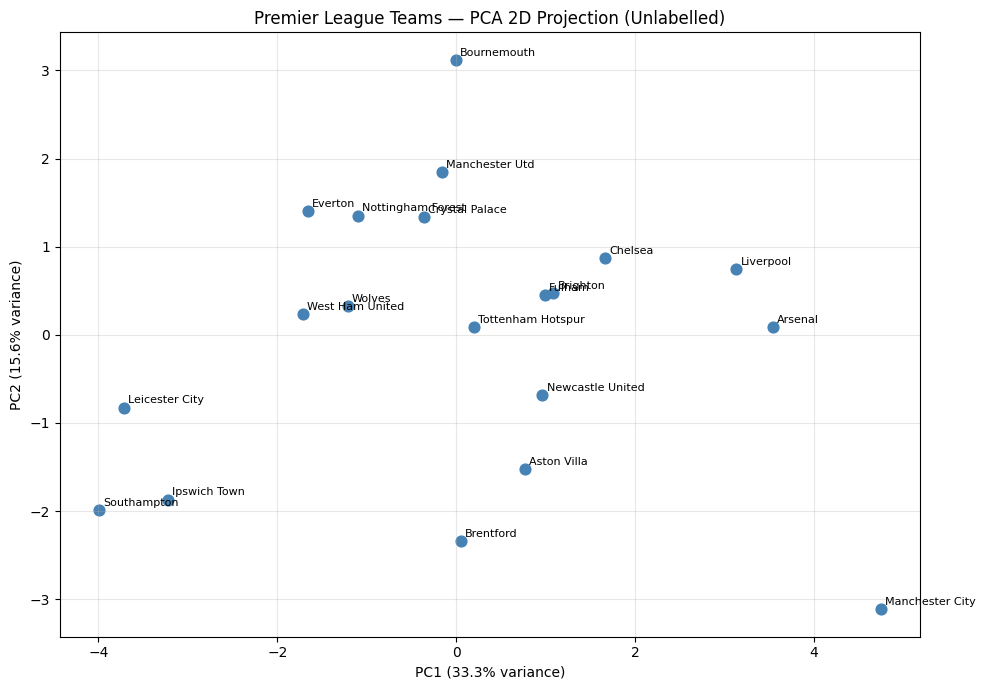

In [17]:
# Project onto first 2 PCs for 2D visualisation (exploration only — not used for clustering)
pca_2d = PCA(n_components=2)
data_2d = pca_2d.fit_transform(data_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(data_2d[:, 0], data_2d[:, 1], color='steelblue', s=60)

for i, team in enumerate(data_style.index):
    plt.annotate(team, (data_2d[i, 0], data_2d[i, 1]), fontsize=8,
                 xytext=(3, 3), textcoords='offset points')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Premier League Teams — PCA 2D Projection (Unlabelled)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist/figures/fig_pca_2d_unlabelled.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Clustering with K-Means and GMM

We apply two unsupervised learning algorithms to the **20 × 15 scaled feature matrix**:

- **K-Means** — hard cluster assignments; minimises within-cluster sum of squares (inertia)
- **GMM** — probabilistic soft assignments; models each cluster as a multivariate Gaussian fitted via the EM algorithm

Both methods require the number of clusters $k$ to be specified in advance. We select $k$ using:
- **Elbow method** (K-Means) — identify where inertia reduction flattens
- **Bayesian Information Criterion / BIC** (GMM) — lower BIC indicates better fit with fewer parameters

In [18]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Evaluate k = 1 to 10 to determine the optimal number of clusters
kmeans_scores = []  # inertia (within-cluster sum of squares) — lower is better
gmm_scores = []     # BIC score — lower is better, penalises model complexity

for k in range(1, 11):
    # K-Means: k-means++ initialisation with 10 restarts avoids poor local minima
    km = KMeans(n_clusters=k, init='k-means++', max_iter=200, n_init=10, random_state=0)
    km.fit(data_scaled)
    kmeans_scores.append(km.inertia_)

    # GMM: 10 initialisations for numerical stability
    gm = GaussianMixture(n_components=k, random_state=123, n_init=10)
    gm.fit(data_scaled)
    gmm_scores.append(gm.bic(data_scaled))

    print(f"k={k}: KMeans inertia={km.inertia_:.2f}, GMM BIC={gm.bic(data_scaled):.2f}")

k=1: KMeans inertia=300.00, GMM BIC=809.27
k=2: KMeans inertia=233.14, GMM BIC=-178.86
k=3: KMeans inertia=192.95, GMM BIC=-596.04
k=4: KMeans inertia=163.64, GMM BIC=-657.32
k=5: KMeans inertia=140.77, GMM BIC=-367.54
k=6: KMeans inertia=128.54, GMM BIC=-217.81
k=7: KMeans inertia=104.50, GMM BIC=9.87
k=8: KMeans inertia=88.91, GMM BIC=363.32
k=9: KMeans inertia=73.93, GMM BIC=651.05
k=10: KMeans inertia=69.81, GMM BIC=972.49


### 4.1 Model Selection: Elbow Method (K-Means) & BIC (GMM)

Both criteria point to **k = 3**:
- **K-Means:** inertia drops steeply from k=1 (300) to k=3 (193), then flattens — the "elbow" is at k=3
- **GMM:** BIC reaches its minimum at k=3 (−596), indicating the best balance of fit and model parsimony

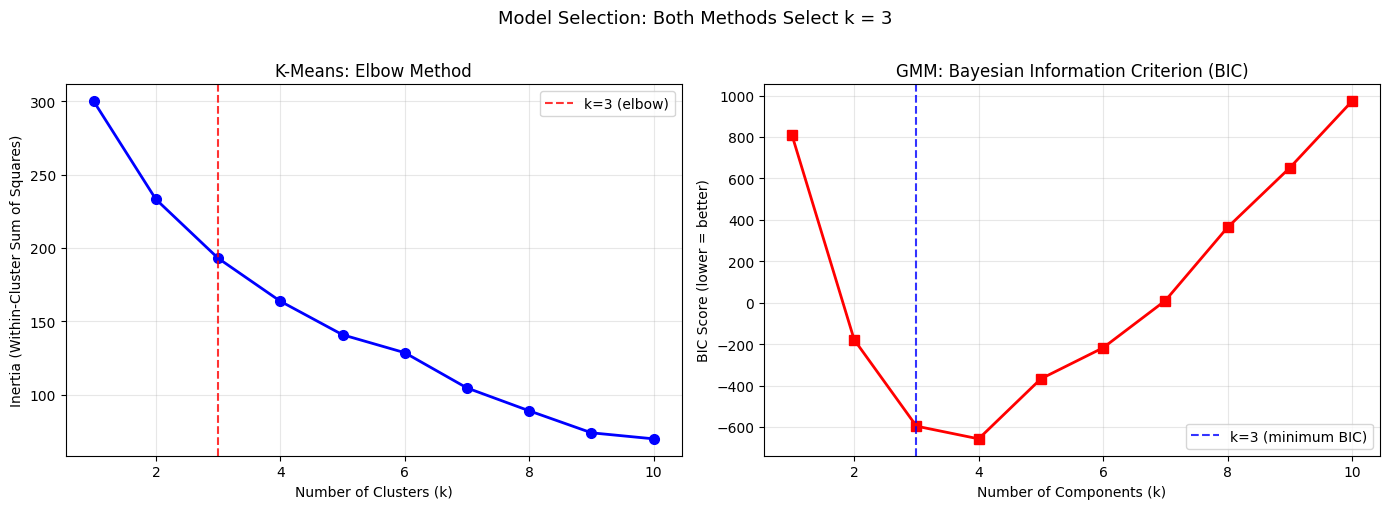

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# K-Means elbow plot
ax1.plot(range(1, 11), kmeans_scores, 'bo-', linewidth=2, markersize=7)
ax1.axvline(x=3, color='r', linestyle='--', alpha=0.8, label='k=3 (elbow)')
ax1.set_title('K-Means: Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# GMM BIC plot
ax2.plot(range(1, 11), gmm_scores, 'rs-', linewidth=2, markersize=7)
ax2.axvline(x=3, color='b', linestyle='--', alpha=0.8, label='k=3 (minimum BIC)')
ax2.set_title('GMM: Bayesian Information Criterion (BIC)')
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('BIC Score (lower = better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Selection: Both Methods Select k = 3', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('dist/figures/fig_elbow_bic.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 K-Means Clustering (k = 3)

We fit K-Means with k = 3 and print the team membership and centroid for each cluster.

In [20]:
k_best = 3

km = KMeans(n_clusters=k_best, init='k-means++', max_iter=200, n_init=10, random_state=0)
km_labels = km.fit_predict(data_scaled)

print("=== K-Means Clusters (k=3) ===")
for c in range(k_best):
    teams = data_style.index[km_labels == c].tolist()
    print(f"Cluster {c}: {teams}")

=== K-Means Clusters (k=3) ===
Cluster 0: ['Arsenal', 'Aston Villa', 'Brighton', 'Chelsea', 'Fulham', 'Liverpool', 'Manchester City', 'Newcastle United', 'Tottenham Hotspur']
Cluster 1: ['Ipswich Town', 'Leicester City', 'Southampton', 'West Ham United']
Cluster 2: ['Bournemouth', 'Brentford', 'Crystal Palace', 'Everton', 'Manchester Utd', 'Nottingham Forest', 'Wolves']


### 4.3 Gaussian Mixture Model Clustering (k = 3)

GMM fits three multivariate Gaussian components via the EM algorithm. Cluster labels are assigned by the highest posterior probability (hard assignment from `predict`).

In [21]:
gm = GaussianMixture(n_components=k_best, random_state=123, n_init=10)
gm.fit(data_scaled)
gmm_labels = gm.predict(data_scaled)

print("=== GMM Clusters (k=3) ===")
for c in range(k_best):
    teams = data_style.index[gmm_labels == c].tolist()
    print(f"Cluster {c}: {teams}")

=== GMM Clusters (k=3) ===
Cluster 0: ['Brighton', 'Crystal Palace', 'Fulham', 'Manchester Utd', 'Tottenham Hotspur', 'Wolves']
Cluster 1: ['Bournemouth', 'Brentford', 'Everton', 'Ipswich Town', 'Leicester City', 'Nottingham Forest', 'Southampton', 'West Ham United']
Cluster 2: ['Arsenal', 'Aston Villa', 'Chelsea', 'Liverpool', 'Manchester City', 'Newcastle United']


### 4.4 GMM Soft Assignment Probabilities

GMM's theoretical advantage over K-Means is **soft assignment**: each team receives a probability for each cluster, not a hard label. With $n=20$ and 15 features, however, we expect the posterior probabilities to become near-deterministic.

## 6. Conclusions

Both K-Means and GMM successfully identify **three playing style groups** within the 2024–25 EPL:

| Style | K-Means (k=3) | GMM (k=3) |
|---|---|---|
| **Attacking** | 9 teams (incl. Spurs, Brighton) | 6 teams (core elite only) |
| **Balanced** | 4 teams | 6 teams (incl. Spurs, Brighton) |
| **Defensive** | 7 teams (highest TklW) | 8 teams (lowest poss/shots) |

**Key findings:**
- A **core attacking group** (Arsenal, Aston Villa, Chelsea, Liverpool, Manchester City, Newcastle United) is robustly identified by both methods — high possession (≈56%), high shots (≈15/90), low tackles
- **Defensive-style teams** (K-Means: Bournemouth, Brentford etc.) win the most tackles per 90 (TklW ≈ 11.4), reflecting a low-block or counter-pressing approach
- The main divergence is Tottenham and Brighton — K-Means places them in the attacking group (high possession), GMM places them in the balanced group (below-elite attacking output)
- **GMM soft assignments** collapsed to hard 0/1 due to the small sample (20 teams, 15 features), negating the probabilistic advantage

See `dist/report.tex` for the full academic write-up and references.

In [22]:
probs = gm.predict_proba(data_scaled)

probs_df = pd.DataFrame(
    probs,
    index=data_style.index,
    columns=[f'Cluster {i}' for i in range(k_best)]
).round(3)

print("=== GMM Cluster Probabilities ===")
probs_df

=== GMM Cluster Probabilities ===


,Cluster 0,Cluster 1,Cluster 2
Squad,,,
Arsenal,0.0,0.0,1.0
Aston Villa,0.0,0.0,1.0
Bournemouth,0.0,1.0,0.0
Brentford,0.0,1.0,0.0
Brighton,1.0,0.0,0.0
Chelsea,0.0,0.0,1.0
Crystal Palace,1.0,0.0,0.0
Everton,0.0,1.0,0.0
Fulham,1.0,0.0,0.0


### 4.5 Detailed Cluster Analysis (Helper Functions)

The helper functions below refit each model and print full cluster membership and centroid statistics for any value of k. We use them here to confirm the k = 4 results are less interpretable than k = 3.

In [23]:
def list_clusters_kmeans(data_scaled, data_style, n_clusters):
    model = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=200,
                   n_init=10, random_state=0)
    model.fit(data_scaled)
    labels = model.labels_

    print(f'\nThere are {n_clusters} clusters with inertia score of {model.inertia_:.2f}\n')

    for label in range(n_clusters):
        teams = data_style.index[labels == label].tolist()
        centre = data_style.loc[teams].mean().round(2).to_dict()
        print(f'Cluster {label} has {len(teams)} teams: {teams}')
        print(f'Centre: {centre}\n')

    return labels

def list_clusters_gmm(data_scaled, data_style, n_clusters):
    model = GaussianMixture(n_components=n_clusters, random_state=123, n_init=10)
    model.fit(data_scaled)
    labels = model.predict(data_scaled)
    score = model.bic(data_scaled)

    print(f'\nThere are {n_clusters} clusters with BIC score of {score:.2f}\n')

    for label in range(n_clusters):
        teams = data_style.index[labels == label].tolist()
        centre = data_style.loc[teams].mean().round(2).to_dict()
        print(f'Cluster {label} has {len(teams)} teams: {teams}')
        print(f'Centre: {centre}\n')

    return labels

### 4.6 Sensitivity Analysis: Exploring k = 4

We run both methods with k = 4 to verify that k = 3 is a robust choice. At k = 4, K-Means isolates Brentford as a singleton cluster, indicating it is an outlier rather than a genuinely distinct style group. GMM at k = 4 splits the dominant group but produces less interpretable boundaries. This confirms k = 3 as the most meaningful solution.

In [24]:
print("=== K-Means Cluster Analysis (k=4) ===")
km_labels = list_clusters_kmeans(data_scaled, data_style, 4)

=== K-Means Cluster Analysis (k=4) ===

There are 4 clusters with inertia score of 163.64

Cluster 0 has 1 teams: ['Brentford']
Centre: {'Poss': 47.9, 'CrdY': 1.63, 'CrdR': 0.03, 'Sh': 11.4, 'SoT': 4.55, 'SoT%': 39.9, 'Fls': 8.42, 'Fld': 8.92, 'Off': 1.66, 'Crs': 17.7, 'Int': 7.5, 'TklW': 10.0, 'SoTA': 5.45, 'Saves': 4.03, 'Save%': 72.9}

Cluster 1 has 10 teams: ['Bournemouth', 'Brighton', 'Crystal Palace', 'Everton', 'Fulham', 'Manchester Utd', 'Nottingham Forest', 'Tottenham Hotspur', 'West Ham United', 'Wolves']
Centre: {'Poss': 48.27, 'CrdY': 2.17, 'CrdR': 0.07, 'Sh': 12.92, 'SoT': 4.36, 'SoT%': 33.74, 'Fls': 11.62, 'Fld': 10.65, 'Off': 1.77, 'Crs': 18.14, 'Int': 8.63, 'TklW': 11.33, 'SoTA': 4.31, 'Saves': 2.9, 'Save%': 68.59}

Cluster 2 has 3 teams: ['Ipswich Town', 'Leicester City', 'Southampton']
Centre: {'Poss': 44.83, 'CrdY': 2.36, 'CrdR': 0.07, 'Sh': 9.18, 'SoT': 2.9, 'SoT%': 31.6, 'Fls': 11.5, 'Fld': 10.67, 'Off': 1.44, 'Crs': 14.67, 'Int': 8.2, 'TklW': 10.07, 'SoTA': 5.83, 

In [25]:
print("=== GMM Cluster Analysis (k=4) ===")
gmm_labels = list_clusters_gmm(data_scaled, data_style, 4)

=== GMM Cluster Analysis (k=4) ===

There are 4 clusters with BIC score of -657.32

Cluster 0 has 6 teams: ['Arsenal', 'Aston Villa', 'Chelsea', 'Manchester City', 'Newcastle United', 'Tottenham Hotspur']
Centre: {'Poss': 55.3, 'CrdY': 1.96, 'CrdR': 0.07, 'Sh': 14.17, 'SoT': 4.77, 'SoT%': 33.7, 'Fls': 10.41, 'Fld': 11.68, 'Off': 1.66, 'Crs': 18.2, 'Int': 6.84, 'TklW': 9.54, 'SoTA': 3.95, 'Saves': 2.72, 'Save%': 70.68}

Cluster 1 has 5 teams: ['Bournemouth', 'Brentford', 'Brighton', 'Fulham', 'Liverpool']
Centre: {'Poss': 51.74, 'CrdY': 2.02, 'CrdR': 0.06, 'Sh': 14.14, 'SoT': 4.89, 'SoT%': 34.82, 'Fls': 11.28, 'Fld': 9.82, 'Off': 1.48, 'Crs': 20.16, 'Int': 8.17, 'TklW': 10.58, 'SoTA': 4.33, 'Saves': 3.02, 'Save%': 70.68}

Cluster 2 has 5 teams: ['Crystal Palace', 'Everton', 'Manchester Utd', 'Nottingham Forest', 'Wolves']
Centre: {'Poss': 45.3, 'CrdY': 2.2, 'CrdR': 0.07, 'Sh': 12.26, 'SoT': 4.21, 'SoT%': 34.38, 'Fls': 11.22, 'Fld': 10.53, 'Off': 1.98, 'Crs': 16.32, 'Int': 8.72, 'TklW': 

## 5. Comparison and Visualisation

Side-by-side 3D scatter plot comparing K-Means and GMM cluster assignments across three key style dimensions: **Possession**, **Shots**, and **Tackles Won**.

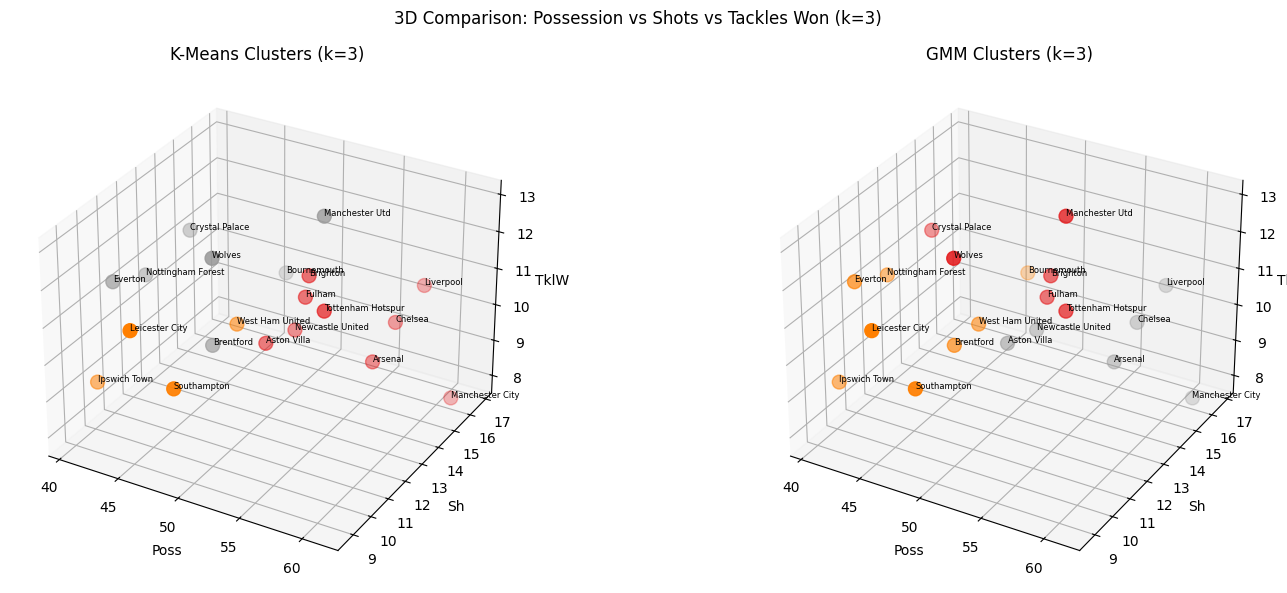

In [26]:
from mpl_toolkits.mplot3d import Axes3D

# Recompute k=3 labels explicitly for this visualisation
# (km_labels and gmm_labels were overwritten by the k=4 analysis above)
km_vis = KMeans(n_clusters=k_best, init='k-means++', max_iter=200, n_init=10, random_state=0)
km_labels_vis = km_vis.fit_predict(data_scaled)

gm_vis = GaussianMixture(n_components=k_best, random_state=123, n_init=10)
gm_vis.fit(data_scaled)
gmm_labels_vis = gm_vis.predict(data_scaled)

# 3D scatter: Possession vs Shots vs Tackles Won — key style dimensions
x_axis = 'Poss'
y_axis = 'Sh'
z_axis = 'TklW'

fig = plt.figure(figsize=(16, 6))

# K-Means k=3 — 3D scatter
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(data_style[x_axis], data_style[y_axis], data_style[z_axis],
            c=km_labels_vis, cmap=plt.colormaps['Set1'], s=100)
for i, team in enumerate(data_style.index):
    ax1.text(data_style[x_axis].iloc[i], data_style[y_axis].iloc[i],
             data_style[z_axis].iloc[i], team, fontsize=6)
ax1.set_xlabel(x_axis)
ax1.set_ylabel(y_axis)
ax1.set_zlabel(z_axis)
ax1.set_title(f'K-Means Clusters (k={k_best})')

# GMM k=3 — 3D scatter
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(data_style[x_axis], data_style[y_axis], data_style[z_axis],
            c=gmm_labels_vis, cmap=plt.colormaps['Set1'], s=100)
for i, team in enumerate(data_style.index):
    ax2.text(data_style[x_axis].iloc[i], data_style[y_axis].iloc[i],
             data_style[z_axis].iloc[i], team, fontsize=6)
ax2.set_xlabel(x_axis)
ax2.set_ylabel(y_axis)
ax2.set_zlabel(z_axis)
ax2.set_title(f'GMM Clusters (k={k_best})')

plt.suptitle('3D Comparison: Possession vs Shots vs Tackles Won (k=3)', fontsize=12)
plt.tight_layout()
plt.savefig('dist/figures/fig_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusions

Both K-Means and GMM successfully identify **three meaningful playing style groups** within the 2024–25 EPL:

| Cluster | K-Means (k=3) | GMM (k=3) |
|---|---|---|
| Elite / Dominant | 9 teams (incl. Spurs, Brighton) | 6 teams (core elite only) |
| Mid-table / Resilient | 7 teams | 6 teams |
| Struggling / Lower-half | 4 teams | 8 teams |

**Key findings:**
- A **core elite group** (Arsenal, Aston Villa, Chelsea, Liverpool, Manchester City, Newcastle United) is robustly identified by both methods
- The main divergence is Tottenham and Brighton — high possession but below elite in attacking output — placed in the dominant group by K-Means and the mid-table group by GMM
- **GMM soft assignments** collapsed to hard 0/1 due to the small sample (20 teams, 15 features), negating the probabilistic advantage
- Cluster profiles align with tactical intuition: elite sides dominate possession and shots; struggling sides have low shot volumes and face many shots against

See `dist/report.tex` for the full academic write-up and references.